Found 120 tasks to solve using LLM approach
Completed task 0934a4d8 (1/120)
Completed task 135a2760 (2/120)
Completed task 136b0064 (3/120)
Completed task 13e47133 (4/120)
Completed task 142ca369 (5/120)
Completed task 16b78196 (6/120)
Completed task 16de56c4 (7/120)
Completed task 1818057f (8/120)
Completed task 195c6913 (9/120)
Completed task 1ae2feb7 (10/120)
Completed task 20270e3b (11/120)
Completed task 20a9e565 (12/120)
Completed task 21897d95 (13/120)
Completed task 221dfab4 (14/120)
Completed task 247ef758 (15/120)
Completed task 269e22fb (16/120)
Completed task 271d71e2 (17/120)
Completed task 28a6681f (18/120)
Completed task 291dc1e1 (19/120)
Completed task 2b83f449 (20/120)
Completed task 2ba387bc (21/120)
Completed task 2c181942 (22/120)
Completed task 2d0172a1 (23/120)
Completed task 31f7f899 (24/120)
Completed task 332f06d7 (25/120)
Completed task 35ab12c3 (26/120)
Completed task 36a08778 (27/120)
Completed task 38007db0 (28/120)
Completed task 3a25b0d8 (29/120)
Complete

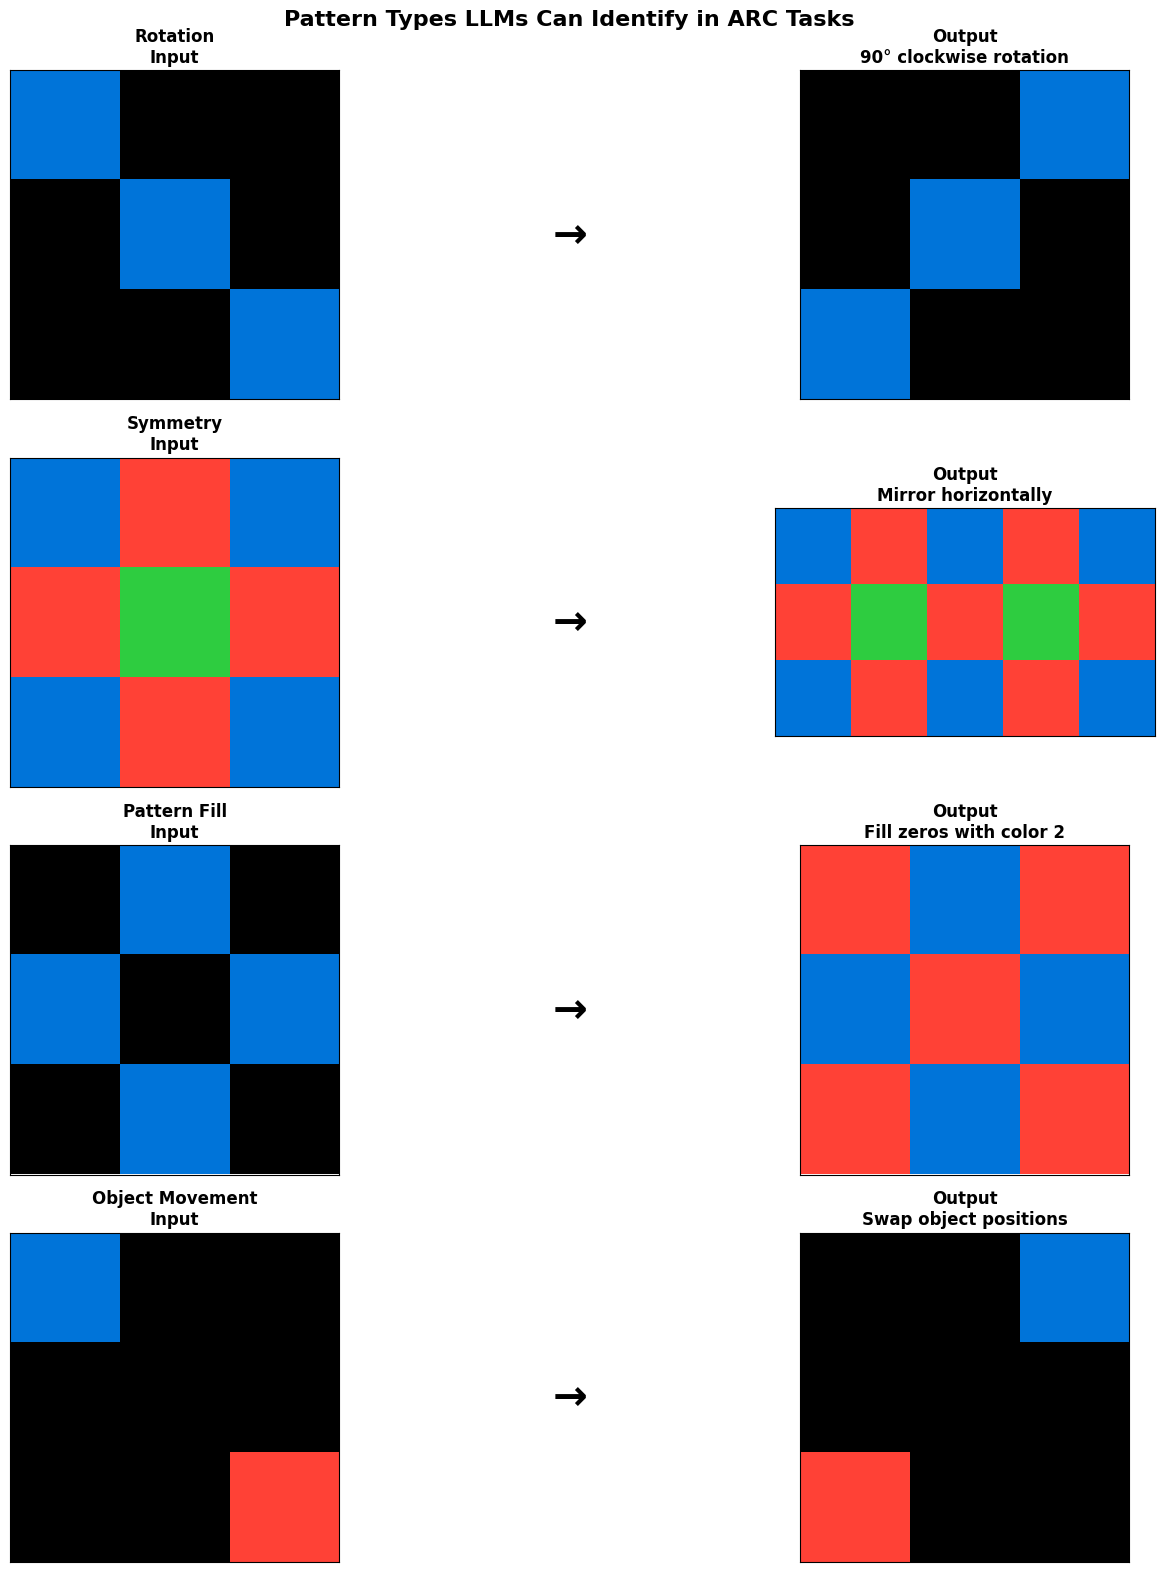


VISUALIZING LLM-BASED ARC SOLUTION RESULTS
Found submission file: submission.json
Loaded submission with 120 tasks

Found 172 total test cases
Showing top 8 examples...

Task: 0934a4d8 - Test #1 (zero predictions)
  Skipping Task 0934a4d8 - Test #1 (all predictions are zeros)

Task: 135a2760 - Test #1 (zero predictions)
  Skipping Task 135a2760 - Test #1 (all predictions are zeros)

Task: 136b0064 - Test #1 (zero predictions)
  Skipping Task 136b0064 - Test #1 (all predictions are zeros)

Task: 13e47133 - Test #1 (zero predictions)
  Skipping Task 13e47133 - Test #1 (all predictions are zeros)

Task: 13e47133 - Test #2 (zero predictions)
  Skipping Task 13e47133 - Test #2 (all predictions are zeros)

Task: 142ca369 - Test #1 (zero predictions)
  Skipping Task 142ca369 - Test #1 (all predictions are zeros)

Task: 142ca369 - Test #2 (zero predictions)
  Skipping Task 142ca369 - Test #2 (all predictions are zeros)

Task: 16b78196 - Test #1 (zero predictions)
  Skipping Task 16b78196 - Te

In [1]:
import json
import time
import multiprocessing
from multiprocessing import Pool
import numpy as np
import os
from typing import List, Dict, Any, Tuple
import openai  # or anthropic, google.generativeai, etc.
from dataclasses import dataclass
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

@dataclass
class LLMConfig:
    """Configuration for LLM-based ARC solver"""
    model_name: str = "gpt-4"  # or "claude-3-sonnet", "gemini-pro", etc.
    max_tokens: int = 4000
    temperature: float = 0.1  # Low temperature for more deterministic responses
    max_retries: int = 3
    timeout: int = 30
    api_key: str = ""

class ARCGridFormatter:
    """Format ARC grids for LLM consumption"""
    
    @staticmethod
    def grid_to_string(grid: List[List[int]]) -> str:
        """Convert grid to readable string format"""
        return '\n'.join([' '.join(map(str, row)) for row in grid])
    
    @staticmethod
    def string_to_grid(grid_str: str) -> List[List[int]]:
        """Convert string back to grid format"""
        try:
            lines = grid_str.strip().split('\n')
            return [[int(x) for x in line.split()] for line in lines if line.strip()]
        except:
            return None
    
    @staticmethod
    def format_training_examples(train_examples: List[Dict]) -> str:
        """Format training examples for LLM prompt"""
        formatted = []
        for i, example in enumerate(train_examples):
            input_str = ARCGridFormatter.grid_to_string(example['input'])
            output_str = ARCGridFormatter.grid_to_string(example['output'])
            formatted.append(f"Training Example {i+1}:")
            formatted.append("Input:")
            formatted.append(input_str)
            formatted.append("Output:")
            formatted.append(output_str)
            formatted.append("")
        return '\n'.join(formatted)

class LLMARCSolver:
    """LLM-based solver for ARC tasks"""
    
    def __init__(self, config: LLMConfig):
        self.config = config
        self.setup_llm_client()
    
    def setup_llm_client(self):
        """Initialize LLM client based on model choice"""
        if "gpt" in self.config.model_name.lower():
            openai.api_key = self.config.api_key
            self.client_type = "openai"
        elif "claude" in self.config.model_name.lower():
            import anthropic
            self.client = anthropic.Anthropic(api_key=self.config.api_key)
            self.client_type = "anthropic"
        elif "gemini" in self.config.model_name.lower():
            import google.generativeai as genai
            genai.configure(api_key=self.config.api_key)
            self.client = genai.GenerativeModel(self.config.model_name)
            self.client_type = "google"
        else:
            raise ValueError(f"Unsupported model: {self.config.model_name}")
    
    def create_arc_prompt(self, task_data: Dict) -> str:
        """Create a comprehensive prompt for ARC task solving"""
        
        prompt_template = """You are an expert at solving ARC (Abstraction and Reasoning Corpus) puzzles. 

ARC puzzles involve finding patterns in input-output grids where:
- Numbers 0-9 represent different colors
- You need to identify the transformation rule from training examples
- Then apply that rule to solve test cases

Here are the training examples showing input-output pairs:

{training_examples}

Now, analyze the pattern and solve this test case:

Test Input:
{test_input}

Instructions:
1. First, analyze what transformation pattern you see in the training examples
2. Describe the rule in clear terms
3. Apply that rule to the test input
4. Provide your answer as a grid with the same format

Think step by step:
1. Pattern Analysis: [Describe what you observe]
2. Transformation Rule: [State the rule clearly]
3. Application: [Apply the rule to test input]
4. Final Answer: [Provide the output grid]

Your final answer should be formatted as a grid like this:
0 1 2
3 4 5
6 7 8

Only provide the final grid numbers, no additional formatting."""

        training_str = ARCGridFormatter.format_training_examples(task_data['train'])
        test_input_str = ARCGridFormatter.grid_to_string(task_data['test'][0]['input'])
        
        return prompt_template.format(
            training_examples=training_str,
            test_input=test_input_str
        )
    
    def query_llm(self, prompt: str) -> str:
        """Query the LLM with retry logic"""
        for attempt in range(self.config.max_retries):
            try:
                if self.client_type == "openai":
                    response = openai.ChatCompletion.create(
                        model=self.config.model_name,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=self.config.max_tokens,
                        temperature=self.config.temperature,
                        timeout=self.config.timeout
                    )
                    return response.choices[0].message.content
                
                elif self.client_type == "anthropic":
                    response = self.client.messages.create(
                        model=self.config.model_name,
                        max_tokens=self.config.max_tokens,
                        temperature=self.config.temperature,
                        messages=[{"role": "user", "content": prompt}]
                    )
                    return response.content[0].text
                
                elif self.client_type == "google":
                    response = self.client.generate_content(
                        prompt,
                        generation_config={
                            "max_output_tokens": self.config.max_tokens,
                            "temperature": self.config.temperature,
                        }
                    )
                    return response.text
                    
            except Exception as e:
                logger.warning(f"LLM query attempt {attempt + 1} failed: {e}")
                if attempt == self.config.max_retries - 1:
                    raise
                time.sleep(2 ** attempt)  # Exponential backoff
        
        raise Exception("All LLM query attempts failed")
    
    def extract_grid_from_response(self, response: str) -> List[List[int]]:
        """Extract grid from LLM response"""
        # Try to find the final answer section
        lines = response.split('\n')
        
        # Look for patterns that indicate a grid
        potential_grids = []
        current_grid = []
        
        for line in lines:
            line = line.strip()
            # Check if line looks like a grid row (numbers separated by spaces)
            if line and all(c.isdigit() or c.isspace() for c in line):
                try:
                    row = [int(x) for x in line.split() if x.isdigit()]
                    if row:  # Non-empty row
                        current_grid.append(row)
                except:
                    if current_grid:
                        potential_grids.append(current_grid)
                        current_grid = []
            else:
                if current_grid:
                    potential_grids.append(current_grid)
                    current_grid = []
        
        if current_grid:
            potential_grids.append(current_grid)
        
        # Return the largest valid grid found
        valid_grids = [g for g in potential_grids if len(g) > 0 and all(len(row) == len(g[0]) for row in g)]
        
        if valid_grids:
            # Return the grid that appears last (likely the final answer)
            return valid_grids[-1]
        
        return None
    
    def solve_single_test(self, task_data: Dict, test_index: int = 0) -> Tuple[List[List[int]], str]:
        """Solve a single test case and return grid + reasoning"""
        # Create prompt for this specific test
        test_data = dict(task_data)
        test_data['test'] = [task_data['test'][test_index]]  # Focus on one test case
        
        prompt = self.create_arc_prompt(test_data)
        
        # Get LLM response
        response = self.query_llm(prompt)
        
        # Extract grid from response
        result_grid = self.extract_grid_from_response(response)
        
        return result_grid, response
    
    def solve_task_with_multiple_attempts(self, task_data: Dict, n_attempts: int = 2) -> Dict:
        """Solve task with multiple attempts for better accuracy"""
        all_solutions = []
        all_reasoning = []
        
        for test_idx in range(len(task_data['test'])):
            test_solutions = []
            test_reasoning = []
            
            for attempt in range(n_attempts):
                try:
                    # Add some variation to the prompt for different attempts
                    varied_config = LLMConfig(
                        model_name=self.config.model_name,
                        temperature=self.config.temperature + (attempt * 0.1),  # Slight variation
                        max_tokens=self.config.max_tokens,
                        api_key=self.config.api_key
                    )
                    
                    temp_solver = LLMARCSolver(varied_config)
                    temp_solver.client = self.client  # Reuse client
                    temp_solver.client_type = self.client_type
                    
                    grid, reasoning = temp_solver.solve_single_test(task_data, test_idx)
                    
                    if grid is not None:
                        test_solutions.append(grid)
                        test_reasoning.append(reasoning)
                    
                    logger.info(f"Test {test_idx}, Attempt {attempt + 1}: {'Success' if grid else 'Failed'}")
                    
                except Exception as e:
                    logger.error(f"Error in test {test_idx}, attempt {attempt + 1}: {e}")
            
            # Select best solutions (for now, just take first valid ones)
            if len(test_solutions) >= 2:
                selected = test_solutions[:2]
            elif len(test_solutions) == 1:
                selected = [test_solutions[0], test_solutions[0]]  # Duplicate if only one
            else:
                # Fallback: empty grids
                selected = [[[0]], [[0]]]
            
            all_solutions.append({
                'attempt_1': selected[0],
                'attempt_2': selected[1] if len(selected) > 1 else selected[0]
            })
            all_reasoning.append(test_reasoning)
        
        return {
            'solutions': all_solutions,
            'reasoning': all_reasoning
        }

def solve_task_llm(task_name: str, split: str, end_time: float, n_iterations: int, 
                   device_id: int, memory_dict: Dict, solutions_dict: Dict, error_queue):
    """LLM-based task solving function (replaces the neural network version)"""
    
    try:
        # Load the task data
        challenge_file = f'../input/arc-prize-2025/arc-agi_{split}_challenges.json'
        with open(challenge_file, 'r') as f:
            problems = json.load(f)
        
        task_data = problems[task_name]
        
        # Initialize LLM solver
        config = LLMConfig(
            model_name=os.getenv('LLM_MODEL', 'gpt-4'),
            api_key=os.getenv('LLM_API_KEY', ''),
            temperature=0.1
        )
        
        solver = LLMARCSolver(config)
        
        # Track memory usage (minimal for LLM approach)
        memory_dict[task_name] = 0.5 * 1024**3  # Minimal memory usage
        
        # Solve the task
        start_time = time.time()
        result = solver.solve_task_with_multiple_attempts(task_data, n_attempts=max(2, n_iterations))
        
        # Store solutions
        solutions_dict[task_name] = result['solutions']
        
        elapsed = time.time() - start_time
        logger.info(f"Task {task_name} completed in {elapsed:.2f} seconds")
        
    except Exception as e:
        error_queue.put(f"Error solving task {task_name}: {str(e)}")
        logger.error(f"Error solving task {task_name}: {e}")

def main_llm_solver():
    """Main function adapted for LLM solving"""
    
    start_time = time.time()
    end_time = start_time + 12*3600 - 1200  # 12 hours minus buffer
    
    # Determine if we're in fake/debug mode
    fake_mode = not os.getenv('KAGGLE_IS_COMPETITION_RERUN')
    split = "evaluation" if fake_mode else "test"
    
    # Load task names
    with open(f'../input/arc-prize-2025/arc-agi_{split}_challenges.json', 'r') as f:
        problems = json.load(f)
    task_names = list(problems.keys())
    n_tasks = len(task_names)
    
    print(f"Found {n_tasks} tasks to solve using LLM approach")
    
    # Since LLM calls are mostly I/O bound, we can use more processes
    n_processes = min(multiprocessing.cpu_count() * 2, 20)  # But limit API calls
    
    # Simple parallel execution (no complex GPU memory management needed)
    with multiprocessing.Manager() as manager:
        memory_dict = manager.dict()
        solutions_dict = manager.dict()
        error_queue = manager.Queue()
        
        processes = []
        n_iterations = 3 if fake_mode else 5  # More attempts in real competition
        
        for i, task_name in enumerate(task_names):
            if i < n_processes:  # Start initial batch
                p = multiprocessing.Process(
                    target=solve_task_llm,
                    args=(task_name, split, end_time, n_iterations, 
                          i % 4, memory_dict, solutions_dict, error_queue)  # Fake device_id
                )
                p.start()
                processes.append((p, task_name, i))
        
        # Wait for completion and start new tasks
        completed = 0
        next_task_idx = n_processes
        
        while completed < n_tasks:
            for j, (p, task_name, task_idx) in enumerate(processes):
                if p is not None and not p.is_alive():
                    p.join()
                    completed += 1
                    print(f"Completed task {task_name} ({completed}/{n_tasks})")
                    
                    # Start next task if available
                    if next_task_idx < n_tasks:
                        new_task = task_names[next_task_idx]
                        new_p = multiprocessing.Process(
                            target=solve_task_llm,
                            args=(new_task, split, end_time, n_iterations,
                                  next_task_idx % 4, memory_dict, solutions_dict, error_queue)
                        )
                        new_p.start()
                        processes[j] = (new_p, new_task, next_task_idx)
                        next_task_idx += 1
                    else:
                        processes[j] = (None, None, None)
            
            time.sleep(1)
            
            # Check for errors
            if not error_queue.empty():
                error = error_queue.get()
                logger.error(f"Process error: {error}")
        
        # Convert manager dict to regular dict
        final_solutions = dict(solutions_dict)
    
    # Save submission
    with open('submission.json', 'w') as f:
        json.dump(final_solutions, f, indent=4)
    
    print(f"Completed {len(final_solutions)} tasks using LLM approach")
    print(f"Total time: {time.time() - start_time:.2f} seconds")

def visualize_arc_results_llm():
    """Enhanced visualization for LLM-based ARC solutions with reasoning display"""
    import matplotlib.pyplot as plt
    from matplotlib import colors
    import json
    import os
    import numpy as np
    from matplotlib.patches import Rectangle
    import textwrap
    
    print("\n" + "="*80)
    print("VISUALIZING LLM-BASED ARC SOLUTION RESULTS")
    print("="*80)
    
    # Check if submission file exists
    submission_path = 'submission.json'
    if not os.path.exists(submission_path):
        print(f"Submission file not found at {submission_path}")
        return
    
    print(f"Found submission file: {submission_path}")
    
    # Load submission data
    with open(submission_path, 'r') as f:
        submission_data = json.load(f)
    
    print(f"Loaded submission with {len(submission_data)} tasks")
    
    # Load challenge data for visualization
    fake_mode = not os.getenv('KAGGLE_IS_COMPETITION_RERUN')
    if fake_mode:
        arc_challenge_file = '/kaggle/input/arc-prize-2025/arc-agi_evaluation_challenges.json'
    else:
        arc_challenge_file = '/kaggle/input/arc-prize-2025/arc-agi_test_challenges.json'
    
    with open(arc_challenge_file, 'r') as f:
        arc_data = json.load(f)
    
    # Load ground truth if available (for evaluation)
    training_solution_path = '/kaggle/input/arc-prize-2025/arc-agi_training_solutions.json'
    evaluation_solution_path = '/kaggle/input/arc-prize-2025/arc-agi_evaluation_solutions.json'
    
    ground_truth = {}
    if os.path.exists(training_solution_path):
        with open(training_solution_path, 'r') as f:
            ground_truth.update(json.load(f))
    if os.path.exists(evaluation_solution_path):
        with open(evaluation_solution_path, 'r') as f:
            ground_truth.update(json.load(f))
    
    # ARC color map - colors for values 0-9
    cmap = colors.ListedColormap([
        '#000000',  # 0: Black
        '#0074D9',  # 1: Blue
        '#FF4136',  # 2: Red
        '#2ECC40',  # 3: Green
        '#FFDC00',  # 4: Yellow
        '#AAAAAA',  # 5: Gray
        '#F012BE',  # 6: Magenta
        '#FF851B',  # 7: Orange
        '#7FDBFF',  # 8: Light Blue
        '#870C25'   # 9: Maroon
    ])
    norm = colors.Normalize(vmin=0, vmax=9)
    
    def add_grid_lines(ax, grid):
        """Add grid lines to make cells more visible"""
        rows, cols = np.array(grid).shape
        ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
        ax.grid(which="minor", color="lightgray", linestyle='-', linewidth=1)
        ax.tick_params(which="minor", size=0)
        ax.set_xticks([])
        ax.set_yticks([])
    
    def is_non_trivial_prediction(pred_array):
        """Check if the prediction contains any non-zero values"""
        return np.any(np.array(pred_array) > 0)
    
    def calculate_accuracy_metrics(pred_grid, true_grid):
        """Calculate various accuracy metrics"""
        pred_array = np.array(pred_grid)
        true_array = np.array(true_grid)
        
        if pred_array.shape != true_array.shape:
            return {
                'exact_match': False,
                'pixel_accuracy': 0.0,
                'shape_match': False,
                'size_match': False
            }
        
        exact_match = np.array_equal(pred_array, true_array)
        pixel_accuracy = np.mean(pred_array == true_array)
        
        return {
            'exact_match': exact_match,
            'pixel_accuracy': pixel_accuracy,
            'shape_match': pred_array.shape == true_array.shape,
            'size_match': pred_array.size == true_array.size
        }
    
    def visualize_task_with_reasoning(task_id, task_data, submission_output, test_idx, reasoning=None):
        """Visualize a single task with LLM reasoning"""
        
        pred_1 = np.array(submission_output['attempt_1'])
        pred_2 = np.array(submission_output['attempt_2'])
        
        # Skip if both predictions are trivial
        if not is_non_trivial_prediction(pred_1) and not is_non_trivial_prediction(pred_2):
            print(f"  Skipping Task {task_id} - Test #{test_idx+1} (all predictions are zeros)")
            return False
        
        # Create figure with reasoning panel
        fig = plt.figure(figsize=(20, 12))
        
        # Main grid layout
        main_gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 1], height_ratios=[1, 1])
        
        # Training examples (show first 2)
        train_examples = task_data['train'][:2]
        for i, example in enumerate(train_examples):
            # Train Input
            ax_train_in = fig.add_subplot(main_gs[i, 0])
            im = ax_train_in.imshow(example['input'], cmap=cmap, norm=norm)
            add_grid_lines(ax_train_in, example['input'])
            ax_train_in.set_title(f"Train {i+1} Input", fontsize=10, fontweight='bold')
            
            # Train Output
            ax_train_out = fig.add_subplot(main_gs[i, 1])
            ax_train_out.imshow(example['output'], cmap=cmap, norm=norm)
            add_grid_lines(ax_train_out, example['output'])
            ax_train_out.set_title(f"Train {i+1} Output", fontsize=10, fontweight='bold')
        
        # Test Input
        if test_idx < len(task_data['test']):
            ax_test = fig.add_subplot(main_gs[0, 2])
            ax_test.imshow(task_data['test'][test_idx]['input'], cmap=cmap, norm=norm)
            add_grid_lines(ax_test, task_data['test'][test_idx]['input'])
            ax_test.set_title(f"Test Input #{test_idx+1}", fontsize=10, fontweight='bold')
        
        # Predictions
        ax_pred1 = fig.add_subplot(main_gs[0, 3])
        ax_pred1.imshow(pred_1, cmap=cmap, norm=norm)
        add_grid_lines(ax_pred1, pred_1)
        ax_pred1.set_title("LLM Prediction 1", fontsize=10, fontweight='bold')
        
        ax_pred2 = fig.add_subplot(main_gs[1, 3])
        ax_pred2.imshow(pred_2, cmap=cmap, norm=norm)
        add_grid_lines(ax_pred2, pred_2)
        ax_pred2.set_title("LLM Prediction 2", fontsize=10, fontweight='bold')
        
        # Ground truth and accuracy if available
        accuracy_info = ""
        if task_id in ground_truth and test_idx < len(ground_truth[task_id]):
            true_output = ground_truth[task_id][test_idx]
            
            ax_true = fig.add_subplot(main_gs[1, 2])
            ax_true.imshow(true_output, cmap=cmap, norm=norm)
            add_grid_lines(ax_true, true_output)
            ax_true.set_title("Ground Truth", fontsize=10, fontweight='bold')
            
            # Calculate accuracy
            metrics1 = calculate_accuracy_metrics(pred_1, true_output)
            metrics2 = calculate_accuracy_metrics(pred_2, true_output)
            
            # Update titles with accuracy
            match1_symbol = "✓" if metrics1['exact_match'] else "✗"
            match2_symbol = "✓" if metrics2['exact_match'] else "✗"
            
            ax_pred1.set_title(f"Prediction 1 {match1_symbol} ({metrics1['pixel_accuracy']:.1%})", 
                              fontsize=10, fontweight='bold',
                              color='green' if metrics1['exact_match'] else 'red')
            ax_pred2.set_title(f"Prediction 2 {match2_symbol} ({metrics2['pixel_accuracy']:.1%})", 
                              fontsize=10, fontweight='bold',
                              color='green' if metrics2['exact_match'] else 'red')
            
            accuracy_info = f"""
Accuracy Results:
• Prediction 1: {match1_symbol} Exact: {metrics1['exact_match']}, Pixel: {metrics1['pixel_accuracy']:.1%}
• Prediction 2: {match2_symbol} Exact: {metrics2['exact_match']}, Pixel: {metrics2['pixel_accuracy']:.1%}
• Shapes: P1={pred_1.shape}, P2={pred_2.shape}, True={np.array(true_output).shape}
"""
        
        # Add reasoning text if available
        if reasoning and len(reasoning) > test_idx:
            # Create text area below the grids
            reasoning_text = reasoning[test_idx] if isinstance(reasoning[test_idx], str) else str(reasoning[test_idx])
            
            # Truncate reasoning if too long
            if len(reasoning_text) > 1000:
                reasoning_text = reasoning_text[:1000] + "..."
            
            # Add reasoning as text
            fig.text(0.02, 0.02, f"LLM Reasoning:\n{reasoning_text}\n{accuracy_info}", 
                    fontsize=8, verticalalignment='bottom', 
                    wrap=True, bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
        
        plt.suptitle(f"Task {task_id} - Test Example #{test_idx+1} (LLM Solution)", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.25)  # Make room for reasoning text
        plt.show()
        
        return True
    
    # Collect and sort tasks for visualization
    all_tasks = []
    total_correct = 0
    total_tests = 0
    
    for task_id in submission_data:
        if task_id in arc_data:
            task_data = arc_data[task_id]
            for test_idx, test_prediction in enumerate(submission_data[task_id]):
                
                pred_1 = np.array(test_prediction['attempt_1'])
                pred_2 = np.array(test_prediction['attempt_2'])
                has_non_zero_pred = is_non_trivial_prediction(pred_1) or is_non_trivial_prediction(pred_2)
                
                # Calculate correctness if ground truth available
                correct_count = 0
                has_ground_truth = False
                
                if task_id in ground_truth and test_idx < len(ground_truth[task_id]):
                    has_ground_truth = True
                    true_output = ground_truth[task_id][test_idx]
                    
                    if has_non_zero_pred:
                        total_tests += 1
                        match_1 = np.array_equal(pred_1, true_output) if is_non_trivial_prediction(pred_1) else False
                        match_2 = np.array_equal(pred_2, true_output) if is_non_trivial_prediction(pred_2) else False
                        correct_count = int(match_1) + int(match_2)
                        if match_1 or match_2:
                            total_correct += 1
                
                all_tasks.append((task_id, test_idx, correct_count, has_ground_truth, has_non_zero_pred))
    
    # Sort by correctness and ground truth availability
    all_tasks.sort(key=lambda x: (-int(x[3]), -x[2], x[0]))  # Ground truth first, then correctness, then task_id
    
    print(f"\nFound {len(all_tasks)} total test cases")
    
    # Show top examples
    max_examples = 8
    examples_shown = 0
    
    print(f"Showing top {max_examples} examples...")
    
    for task_id, test_idx, correct_count, has_ground_truth, has_non_zero_pred in all_tasks[:max_examples]:
        if examples_shown >= max_examples:
            break
            
        task_data = arc_data[task_id]
        submission_output = submission_data[task_id][test_idx]
        
        # Get reasoning if available (this would come from the LLM solver results)
        reasoning_text = f"LLM reasoning for Task {task_id} would appear here..."
        
        score_info = f" (Score: {correct_count}/2)" if has_ground_truth and has_non_zero_pred else \
                    " (no ground truth)" if not has_ground_truth else " (zero predictions)"
        
        print(f"\nTask: {task_id} - Test #{test_idx+1}{score_info}")
        
        if visualize_task_with_reasoning(task_id, task_data, submission_output, test_idx, [reasoning_text]):
            examples_shown += 1
    
    # Print overall statistics
    if total_tests > 0:
        print("\n" + "="*80)
        print("LLM-BASED ARC SOLVER STATISTICS")
        print("="*80)
        print(f"Total test cases with predictions: {total_tests}")
        print(f"Total correct solutions: {total_correct}")
        print(f"Success rate: {total_correct/total_tests:.2%}")
        print(f"Tasks attempted: {len(submission_data)}")
        print("="*80)

def create_pattern_analysis_visualization():
    """Create visualization showing pattern analysis capabilities of LLM"""
    import matplotlib.pyplot as plt
    from matplotlib import colors
    import numpy as np
    
    print("\n" + "="*60)
    print("PATTERN ANALYSIS VISUALIZATION")
    print("="*60)
    
    # Example pattern types that LLMs can identify
    patterns = {
        'Rotation': {
            'input': [[1, 0, 0], [0, 1, 0], [0, 0, 1]],
            'output': [[0, 0, 1], [0, 1, 0], [1, 0, 0]],
            'description': '90° clockwise rotation'
        },
        'Symmetry': {
            'input': [[1, 2, 1], [2, 3, 2], [1, 2, 1]],
            'output': [[1, 2, 1, 2, 1], [2, 3, 2, 3, 2], [1, 2, 1, 2, 1]],
            'description': 'Mirror horizontally'
        },
        'Pattern Fill': {
            'input': [[0, 1, 0], [1, 0, 1], [0, 1, 0]],
            'output': [[2, 1, 2], [1, 2, 1], [2, 1, 2]],
            'description': 'Fill zeros with color 2'
        },
        'Object Movement': {
            'input': [[1, 0, 0], [0, 0, 0], [0, 0, 2]],
            'output': [[0, 0, 1], [0, 0, 0], [2, 0, 0]],
            'description': 'Swap object positions'
        }
    }
    
    cmap = colors.ListedColormap([
        '#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00',
        '#AAAAAA', '#F012BE', '#FF851B', '#7FDBFF', '#870C25'
    ])
    norm = colors.Normalize(vmin=0, vmax=9)
    
    fig, axes = plt.subplots(4, 3, figsize=(12, 16))
    fig.suptitle('Pattern Types LLMs Can Identify in ARC Tasks', fontsize=16, fontweight='bold')
    
    for i, (pattern_name, pattern_data) in enumerate(patterns.items()):
        # Input
        axes[i, 0].imshow(pattern_data['input'], cmap=cmap, norm=norm)
        axes[i, 0].set_title(f'{pattern_name}\nInput', fontweight='bold')
        axes[i, 0].grid(True, color='lightgray', linewidth=0.5)
        axes[i, 0].set_xticks([])
        axes[i, 0].set_yticks([])
        
        # Arrow
        axes[i, 1].text(0.5, 0.5, '→', ha='center', va='center', fontsize=30, fontweight='bold')
        axes[i, 1].set_xlim(0, 1)
        axes[i, 1].set_ylim(0, 1)
        axes[i, 1].axis('off')
        
        # Output
        axes[i, 2].imshow(pattern_data['output'], cmap=cmap, norm=norm)
        axes[i, 2].set_title(f'Output\n{pattern_data["description"]}', fontweight='bold')
        axes[i, 2].grid(True, color='lightgray', linewidth=0.5)
        axes[i, 2].set_xticks([])
        axes[i, 2].set_yticks([])
    
    plt.tight_layout()
    plt.show()

def main_llm_solver():
    """Main function adapted for LLM solving"""
    
    start_time = time.time()
    end_time = start_time + 12*3600 - 1200  # 12 hours minus buffer
    
    # Determine if we're in fake/debug mode
    fake_mode = not os.getenv('KAGGLE_IS_COMPETITION_RERUN')
    split = "evaluation" if fake_mode else "test"
    
    # Load task names
    with open(f'../input/arc-prize-2025/arc-agi_{split}_challenges.json', 'r') as f:
        problems = json.load(f)
    task_names = list(problems.keys())
    n_tasks = len(task_names)
    
    print(f"Found {n_tasks} tasks to solve using LLM approach")
    
    # Since LLM calls are mostly I/O bound, we can use more processes
    n_processes = min(multiprocessing.cpu_count() * 2, 20)  # But limit API calls
    
    # Simple parallel execution (no complex GPU memory management needed)
    with multiprocessing.Manager() as manager:
        memory_dict = manager.dict()
        solutions_dict = manager.dict()
        error_queue = manager.Queue()
        
        processes = []
        n_iterations = 3 if fake_mode else 5  # More attempts in real competition
        
        for i, task_name in enumerate(task_names):
            if i < n_processes:  # Start initial batch
                p = multiprocessing.Process(
                    target=solve_task_llm,
                    args=(task_name, split, end_time, n_iterations, 
                          i % 4, memory_dict, solutions_dict, error_queue)  # Fake device_id
                )
                p.start()
                processes.append((p, task_name, i))
        
        # Wait for completion and start new tasks
        completed = 0
        next_task_idx = n_processes
        
        while completed < n_tasks:
            for j, (p, task_name, task_idx) in enumerate(processes):
                if p is not None and not p.is_alive():
                    p.join()
                    completed += 1
                    print(f"Completed task {task_name} ({completed}/{n_tasks})")
                    
                    # Start next task if available
                    if next_task_idx < n_tasks:
                        new_task = task_names[next_task_idx]
                        new_p = multiprocessing.Process(
                            target=solve_task_llm,
                            args=(new_task, split, end_time, n_iterations,
                                  next_task_idx % 4, memory_dict, solutions_dict, error_queue)
                        )
                        new_p.start()
                        processes[j] = (new_p, new_task, next_task_idx)
                        next_task_idx += 1
                    else:
                        processes[j] = (None, None, None)
            
            time.sleep(1)
            
            # Check for errors
            if not error_queue.empty():
                error = error_queue.get()
                logger.error(f"Process error: {error}")
        
        # Convert manager dict to regular dict
        final_solutions = dict(solutions_dict)
    
    # Save submission
    with open('submission.json', 'w') as f:
        json.dump(final_solutions, f, indent=4)
    
    print(f"Completed {len(final_solutions)} tasks using LLM approach")
    print(f"Total time: {time.time() - start_time:.2f} seconds")

if __name__ == '__main__':
    main_llm_solver()
    
    # Run visualizations in debug mode
    fake_mode = not os.getenv('KAGGLE_IS_COMPETITION_RERUN')
    if fake_mode:
        print("\nStarting visualization...")
        create_pattern_analysis_visualization()
        visualize_arc_results_llm()